### Baseline Average

--- Analyzing baseline_exact_10runs.csv ---
Extracting scores...

BASELINE STATISTICS (10 RUNS)
   Run_ID  mean        std  count
0       1  83.4  26.561155    100
1       2  82.9  26.715675    100
2       3  84.8  25.365211    100
3       4  84.3  25.554655    100
4       5  84.3  25.554655    100
5       6  83.4  26.561155    100
6       7  84.8  25.365211    100
7       8  84.8  25.365211    100
8       9  85.3  25.164309    100
9      10  84.4  26.220510    100
----------------------------------------
Global Mean Score: 84.24
Run-to-Run Std Dev: 0.7677

Chart saved as baseline_10runs_errorbar.png


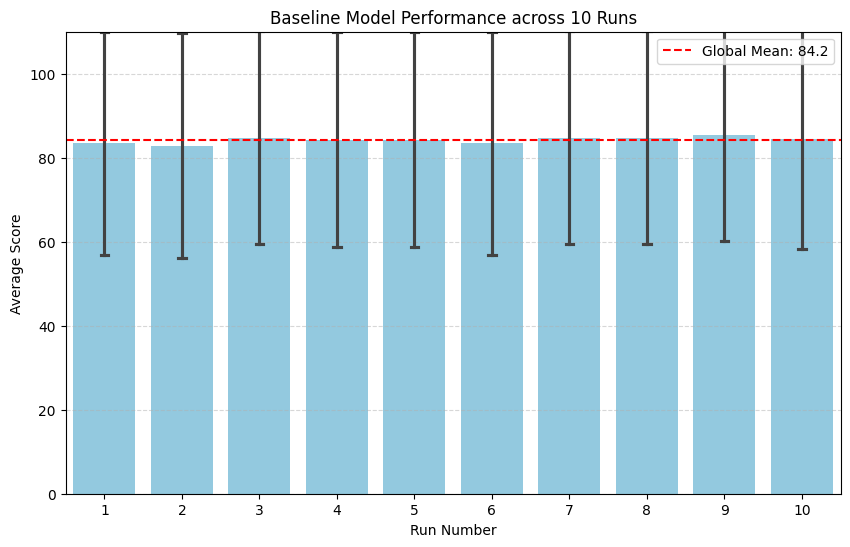

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- Configuration ---
# Make sure the CSV file is located in the exact same directory
FILE_PATH = "baseline_exact_10runs.csv"
OUTPUT_IMAGE = "baseline_10runs_errorbar.png"

def extract_score(row):
    """
    Extract the score using a two-step logic:
    1. Find the selected option (e.g., Option 1)
    2. Find the points assigned to that option in the prompt text
    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. Find the option number (e.g., 1 or 2)
        # Look for patterns like "option 1", "question 1", "choice 2"
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        
        # If not found, perhaps the answer starts with a number like "1." or "1)"
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            # The last matched group is usually the number itself
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
            else:
                return None

            # 2. Find the points for that specific option in the prompt text
            # Looking for the pattern: "1. [text] (100 points)"
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            
            if points_match:
                return int(points_match.group(1))
        
        # 3. Last resort: Direct text search (if the option selection logic fails)
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return

    # Read the dataset
    df = pd.read_csv(FILE_PATH)
    
    # Calculate scores
    print("Extracting scores...")
    df['Score'] = df.apply(extract_score, axis=1)
    
    # Drop invalid or unparsed rows
    df_clean = df.dropna(subset=['Score'])
    
    if len(df_clean) == 0:
        print("Error: No scores could be extracted. Check regex logic.")
        return

    # Calculate statistics for each independent Run
    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"BASELINE STATISTICS (10 RUNS)")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Mean Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")

    # Draw the plot
    plt.figure(figsize=(10, 6))
    
    # Bar plot with error bars showing Standard Deviation
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='skyblue')
    
    # Add a horizontal line for the global mean
    plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Baseline Model Performance across 10 Runs")
    plt.ylabel("Average Score")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

### Core (Money + Reward)

--- Analyzing intersection_all_layers_10runs.csv ---
Extracting scores...

INTERSECTION LESION STATISTICS (10 RUNS)
   Run_ID  mean        std  count
0       1  83.4  26.561155    100
1       2  84.4  26.220510    100
2       3  83.8  25.732894    100
3       4  84.9  26.033972    100
4       5  84.8  25.365211    100
5       6  83.9  26.396166    100
6       7  84.3  25.554655    100
7       8  84.9  26.033972    100
8       9  83.4  26.561155    100
9      10  83.9  26.396166    100
----------------------------------------
Global Mean Score: 84.17
Run-to-Run Std Dev: 0.5774



Chart saved as intersection_10runs_errorbar.png


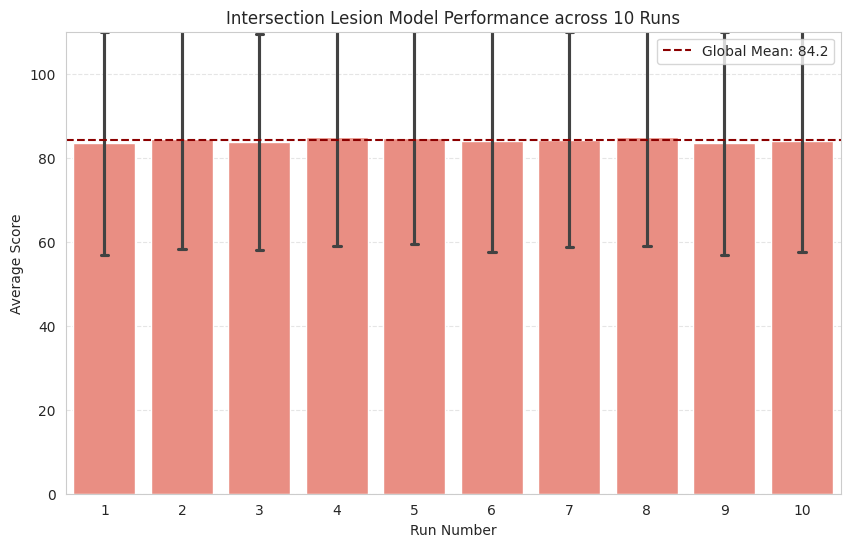

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- Configuration ---
# 1. Update the file path to your new intersection results
FILE_PATH = "intersection_all_layers_10runs.csv"
# 2. Update the output image name
OUTPUT_IMAGE = "intersection_10runs_errorbar.png"

def extract_score(row):
    """
    Extract the score using a two-step logic:
    1. Find the selected option (e.g., Option 1)
    2. Find the points assigned to that option in the prompt text
    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. Find the option number (e.g., 1 or 2)
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        
        # If not found, perhaps the answer starts with a number like "1." or "1)"
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
            else:
                return None

            # 2. Find the points for that specific option in the prompt text
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            
            if points_match:
                return int(points_match.group(1))
        
        # 3. Last resort: Direct text search
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return

    # Read the dataset
    df = pd.read_csv(FILE_PATH)
    
    # Calculate scores
    print("Extracting scores...")
    df['Score'] = df.apply(extract_score, axis=1)
    
    # Drop invalid or unparsed rows
    df_clean = df.dropna(subset=['Score'])
    
    if len(df_clean) == 0:
        print("Error: No scores could be extracted. Check regex logic.")
        return

    # Calculate statistics for each independent Run
    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"INTERSECTION LESION STATISTICS (10 RUNS)")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Mean Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")

    # Draw the plot
    plt.figure(figsize=(10, 6))
    
    # Bar plot with error bars - changed color to 'salmon' to distinguish from baseline
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='salmon')
    
    # Add a horizontal line for the global mean
    plt.axhline(y=overall_mean, color='darkred', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Intersection Lesion Model Performance across 10 Runs")
    plt.ylabel("Average Score")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

### Reward only

--- Analyzing reward_only_all_layers_10runs.csv ---
Extracting scores...

REWARD-ONLY LESION STATISTICS (10 RUNS)
   Run_ID  mean        std  count
0       1  83.9  26.396166    100
1       2  83.9  26.396166    100
2       3  85.3  25.164309    100
3       4  84.8  25.365211    100
4       5  83.4  26.561155    100
5       6  83.9  26.396166    100
6       7  83.9  26.396166    100
7       8  85.3  25.164309    100
8       9  82.9  26.715675    100
9      10  84.8  25.365211    100
----------------------------------------
Global Mean Score: 84.21
Run-to-Run Std Dev: 0.8048



Chart saved as reward_only_10runs_errorbar.png


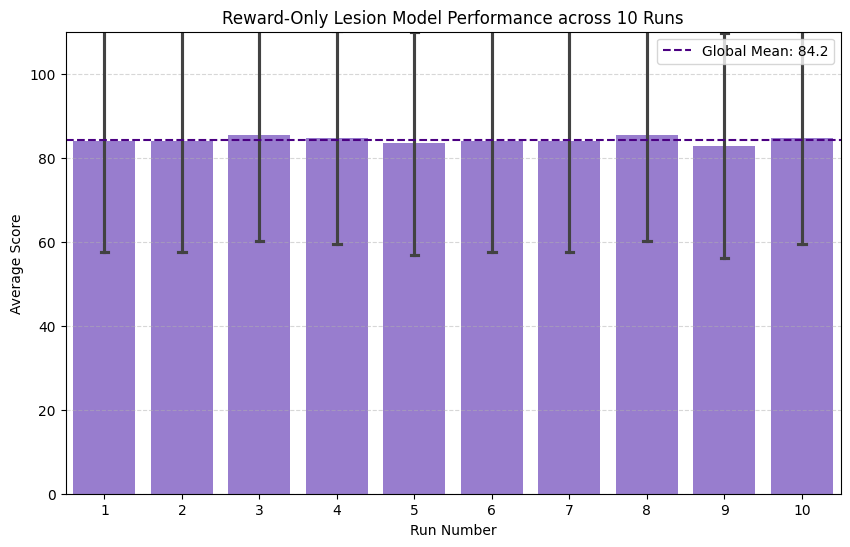

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- Configuration ---
# 1. Update the file path to your new reward-only results
FILE_PATH = "reward_only_all_layers_10runs.csv"
# 2. Update the output image name
OUTPUT_IMAGE = "reward_only_10runs_errorbar.png"

def extract_score(row):
    """
    Extract the score using a two-step logic:
    1. Find the selected option (e.g., Option 1)
    2. Find the points assigned to that option in the prompt text
    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. Find the option number (e.g., 1 or 2)
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        
        # If not found, perhaps the answer starts with a number like "1." or "1)"
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
            else:
                return None

            # 2. Find the points for that specific option in the prompt text
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            
            if points_match:
                return int(points_match.group(1))
        
        # 3. Last resort: Direct text search
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return

    # Read the dataset
    df = pd.read_csv(FILE_PATH)
    
    # Calculate scores
    print("Extracting scores...")
    df['Score'] = df.apply(extract_score, axis=1)
    
    # Drop invalid or unparsed rows
    df_clean = df.dropna(subset=['Score'])
    
    if len(df_clean) == 0:
        print("Error: No scores could be extracted. Check regex logic.")
        return

    # Calculate statistics for each independent Run
    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"REWARD-ONLY LESION STATISTICS (10 RUNS)")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Mean Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")

    # Draw the plot
    plt.figure(figsize=(10, 6))
    
    # Bar plot with error bars - changed color to 'mediumpurple'
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='mediumpurple')
    
    # Add a horizontal line for the global mean
    plt.axhline(y=overall_mean, color='indigo', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Reward-Only Lesion Model Performance across 10 Runs")
    plt.ylabel("Average Score")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

### Money Only

--- Analyzing money_only_all_layers_10runs.csv ---
Extracting scores...

MONEY-ONLY LESION STATISTICS (10 RUNS)
   Run_ID  mean        std  count
0       1  83.9  26.396166    100
1       2  83.4  26.561155    100
2       3  83.9  26.396166    100
3       4  84.8  25.365211    100
4       5  84.4  26.220510    100
5       6  83.9  26.396166    100
6       7  83.4  26.561155    100
7       8  84.8  25.365211    100
8       9  85.3  25.164309    100
9      10  83.4  26.561155    100
----------------------------------------
Global Mean Score: 84.12
Run-to-Run Std Dev: 0.6746

Chart saved as money_only_10runs_errorbar.png


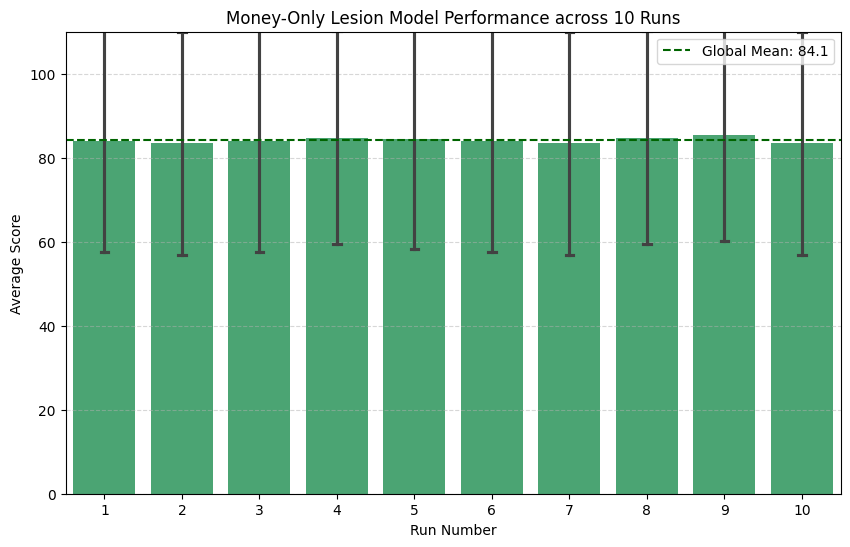

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- Configuration ---
# 1. Update the file path to your new money-only results
FILE_PATH = "money_only_all_layers_10runs.csv"
# 2. Update the output image name
OUTPUT_IMAGE = "money_only_10runs_errorbar.png"

def extract_score(row):
    """
    Extract the score using a two-step logic:
    1. Find the selected option (e.g., Option 1)
    2. Find the points assigned to that option in the prompt text
    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. Find the option number (e.g., 1 or 2)
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        
        # If not found, perhaps the answer starts with a number like "1." or "1)"
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
            else:
                return None

            # 2. Find the points for that specific option in the prompt text
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            
            if points_match:
                return int(points_match.group(1))
        
        # 3. Last resort: Direct text search
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return

    # Read the dataset
    df = pd.read_csv(FILE_PATH)
    
    # Calculate scores
    print("Extracting scores...")
    df['Score'] = df.apply(extract_score, axis=1)
    
    # Drop invalid or unparsed rows
    df_clean = df.dropna(subset=['Score'])
    
    if len(df_clean) == 0:
        print("Error: No scores could be extracted. Check regex logic.")
        return

    # Calculate statistics for each independent Run
    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"MONEY-ONLY LESION STATISTICS (10 RUNS)")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Mean Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")

    # Draw the plot
    plt.figure(figsize=(10, 6))
    
    # Bar plot with error bars - changed color to 'mediumseagreen' for Money
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='mediumseagreen')
    
    # Add a horizontal line for the global mean
    plt.axhline(y=overall_mean, color='darkgreen', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Money-Only Lesion Model Performance across 10 Runs")
    plt.ylabel("Average Score")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

### Money and Reward Union

--- Analyzing union_all_layers_10runs.csv ---
Extracting scores...

UNION LESION STATISTICS (10 RUNS)
   Run_ID  mean        std  count
0       1  85.3  25.164309    100
1       2  84.8  25.365211    100
2       3  84.4  26.220510    100
3       4  85.3  25.164309    100
4       5  84.8  25.365211    100
5       6  83.4  26.561155    100
6       7  84.8  25.365211    100
7       8  82.9  26.715675    100
8       9  83.9  26.396166    100
9      10  84.4  26.220510    100
----------------------------------------
Global Mean Score: 84.40
Run-to-Run Std Dev: 0.7888

Chart saved as union_10runs_errorbar.png


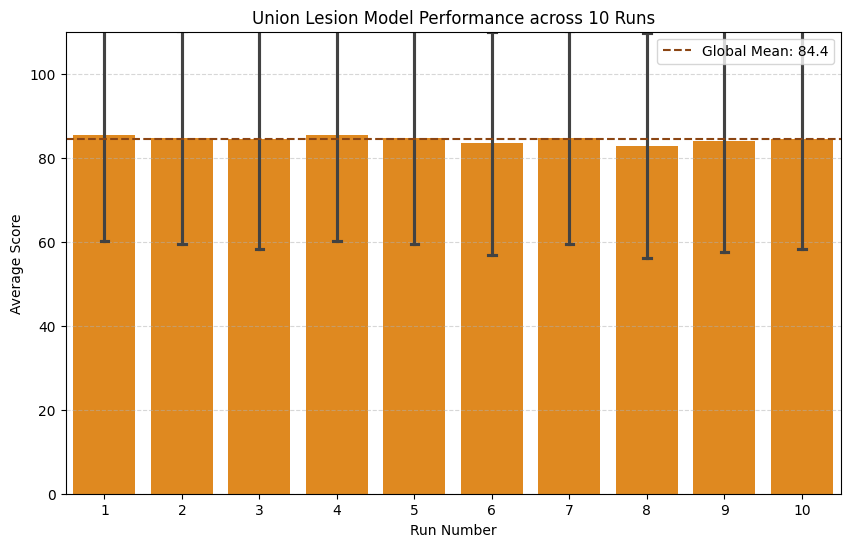

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- Configuration ---
# 1. Update the file path to your new union results
FILE_PATH = "union_all_layers_10runs.csv"
# 2. Update the output image name
OUTPUT_IMAGE = "union_10runs_errorbar.png"

def extract_score(row):
    """
    Extract the score using a two-step logic:
    1. Find the selected option (e.g., Option 1)
    2. Find the points assigned to that option in the prompt text
    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. Find the option number (e.g., 1 or 2)
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        
        # If not found, perhaps the answer starts with a number like "1." or "1)"
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
            else:
                return None

            # 2. Find the points for that specific option in the prompt text
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            
            if points_match:
                return int(points_match.group(1))
        
        # 3. Last resort: Direct text search
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return

    # Read the dataset
    df = pd.read_csv(FILE_PATH)
    
    # Calculate scores
    print("Extracting scores...")
    df['Score'] = df.apply(extract_score, axis=1)
    
    # Drop invalid or unparsed rows
    df_clean = df.dropna(subset=['Score'])
    
    if len(df_clean) == 0:
        print("Error: No scores could be extracted. Check regex logic.")
        return

    # Calculate statistics for each independent Run
    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"UNION LESION STATISTICS (10 RUNS)")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Mean Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")

    # Draw the plot
    plt.figure(figsize=(10, 6))
    
    # Bar plot with error bars - changed color to 'darkorange' for Union
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='darkorange')
    
    # Add a horizontal line for the global mean
    plt.axhline(y=overall_mean, color='saddlebrown', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Union Lesion Model Performance across 10 Runs")
    plt.ylabel("Average Score")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

### Bottom K

--- Analyzing control_bottom_k_all_layers_10runs.csv ---
Extracting scores...

CONTROL (BOTTOM-K) LESION STATISTICS
   Run_ID  mean        std  count
0       1  85.3  25.164309    100
1       2  85.3  25.164309    100
2       3  84.8  25.365211    100
3       4  85.3  25.164309    100
4       5  84.4  26.220510    100
5       6  84.4  26.220510    100
6       7  85.3  25.164309    100
7       8  84.8  25.365211    100
8       9  83.4  26.561155    100
9      10  85.3  25.164309    100
----------------------------------------
Global Mean Score: 84.83
Run-to-Run Std Dev: 0.6255

Chart saved as control_bottom_k_10runs_errorbar.png


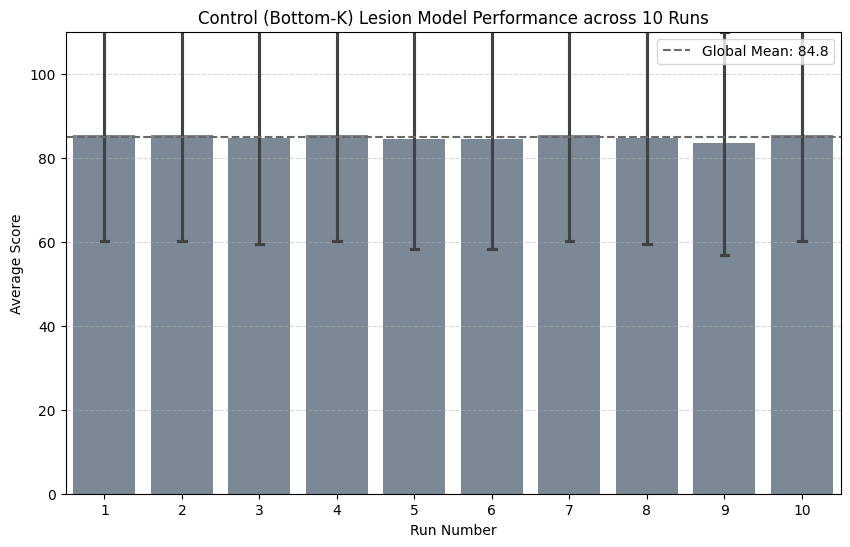

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- Configuration ---
# 1. Update the file path to your new control results
FILE_PATH = "control_bottom_k_all_layers_10runs.csv"
# 2. Update the output image name
OUTPUT_IMAGE = "control_bottom_k_10runs_errorbar.png"

def extract_score(row):
    """
    Extract the score using a two-step logic:
    1. Find the selected option (e.g., Option 1)
    2. Find the points assigned to that option in the prompt text
    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. Find the option number (e.g., 1 or 2)
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        
        # If not found, perhaps the answer starts with a number like "1." or "1)"
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
            else:
                return None

            # 2. Find the points for that specific option in the prompt text
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            
            if points_match:
                return int(points_match.group(1))
        
        # 3. Last resort: Direct text search
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return

    # Read the dataset
    df = pd.read_csv(FILE_PATH)
    
    # Calculate scores
    print("Extracting scores...")
    df['Score'] = df.apply(extract_score, axis=1)
    
    # Drop invalid or unparsed rows
    df_clean = df.dropna(subset=['Score'])
    
    if len(df_clean) == 0:
        print("Error: No scores could be extracted. Check regex logic.")
        return

    # Calculate statistics for each independent Run
    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"CONTROL (BOTTOM-K) LESION STATISTICS")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Mean Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")

    # Draw the plot
    plt.figure(figsize=(10, 6))
    
    # Bar plot with error bars - changed color to 'lightslategray' for Control
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='lightslategray')
    
    # Add a horizontal line for the global mean
    plt.axhline(y=overall_mean, color='dimgray', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Control (Bottom-K) Lesion Model Performance across 10 Runs")
    plt.ylabel("Average Score")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

### Negetive Scaling Factors (core)